In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML

def RK4(x,y,f,h):
  k1 = h*f(x,y)
  k2 = h*f(x+0.5*h, y + 0.5*k1)
  k3 = h*f(x+0.5*h, y + 0.5*k2)
  k4 = h*f(x+h, y + k3)
  return y + (k1 + 2*k2 + 2*k3 + k4)/6

def Mass_on_spring(t,x_v):
  x,v = x_v
  k = 1
  m = 1
  dxdt = x_v[1]
  dvdt = -(k/m) * x_v[0]
  return np.array([dxdt, dvdt])

def Mass_on_spring_vector_field(x_val, v_val):
    k = 1
    m = 1
    dxdt_val = v_val
    dvdt_val = -(k / m) * x_val
    return dxdt_val, dvdt_val

def Pendulum(t,theta_w): #Define ODE
  theta,w = theta_w
  l = 9.81
  g = 9.81
  dthetadt = theta_w[1]
  dwdt = -g/l * np.sin(theta_w[0])
  return np.array([dthetadt, dwdt])

def theta(N0_inputs, initial_theta):
    all_thetas = []
    all_w = []
    theta0 = np.zeros(N0_inputs)

    for i in range(N0_inputs):

        theta0[i] = np.deg2rad(((i**2) + initial_theta))

        t0 = 0

        w0 = 0

        tend = 10

        h = 0.1

        n = int((tend - t0) / h)

        theta_i = np.zeros(n)

        w_i = np.zeros(n)

        t = np.zeros(n)

        t[0] = t0

        theta_i[0] = theta0[i]

        w_i[0] = w0

        for j in range(n-1): # Perform RK4 on ODE
            x_v_current = np.array([theta_i[j], w_i[j]])
            x_v_next = RK4(t[j], x_v_current, Pendulum, h)
            theta_i[j+1] = x_v_next[0]
            w_i[j+1] = x_v_next[1]
            t[j+1] = t[j] + h

        all_thetas.append(theta_i)
        all_w.append(w_i)

    return t, all_thetas, theta0, all_w

def theta_single(N0_inputs, initial_theta):
    all_thetas = []
    theta0 = np.zeros(N0_inputs)

    for i in range(N0_inputs):

        theta0[i] = initial_theta

        t0 = 0

        w0 = 0

        tend = 10

        h = 0.1

        n = int((tend - t0) / h)

        theta_i = np.zeros(n)

        w_i = np.zeros(n)

        t = np.zeros(n)

        t[0] = t0

        theta_i[0] = theta0[i]

        w_i[0] = w0

        for j in range(n-1): # Perform RK4
            x_v_current = np.array([theta_i[j], w_i[j]])
            x_v_next = RK4(t[j], x_v_current, Pendulum, h)
            theta_i[j+1] = x_v_next[0]
            w_i[j+1] = x_v_next[1]
            t[j+1] = t[j] + h

        all_thetas.append(theta_i)

    return t, all_thetas, theta0


def Zero_cross_alg(N0_inputs,theta_init):
  t_out, thetas_out, theta0_out = theta_single(N0_inputs,theta_init)

  zero_crossing_times = []

  for i in range(1, len(thetas_out[0])):
    if np.sign(thetas_out[0][i-1]) != np.sign(thetas_out[0][i]):
       zero_crossing_times.append(t_out[i])

  period_differences = []
  for j in range(len(zero_crossing_times) - 1):
    period_differences.append(zero_crossing_times[j+1] - zero_crossing_times[j])

  period = np.mean(period_differences) * 2

  return period

def omega(N0_inputs, initial_omega):
    all_omega = []
    all_theta = []
    omega0 = np.zeros(N0_inputs)

    for i in range(N0_inputs):

        omega0[i] = (i + initial_omega)*0.3

        t0 = 0

        theta0 = 0

        tend = 50

        h = 0.1

        n = int((tend - t0) / h)

        theta_i = np.zeros(n)

        w_i = np.zeros(n)

        t = np.zeros(n)

        t[0] = t0

        theta_i[0] = theta0

        w_i[0] = omega0[i]

        for j in range(n-1): # Perform RK4 on ODE
            x_v_current = np.array([theta_i[j], w_i[j]])
            x_v_next = RK4(t[j], x_v_current, Pendulum, h)
            theta_i[j+1] = x_v_next[0]
            w_i[j+1] = x_v_next[1]
            t[j+1] = t[j] + h

            if theta_i[j+1] > np.pi:
              theta_i[j+1] = theta_i[j+1] - 2*np.pi
            if theta_i[j+1] < -np.pi:
              theta_i[j+1] = theta_i[j+1] + 2*np.pi

        all_omega.append(w_i)
        all_theta.append(theta_i)

    return t, all_omega, all_theta, omega0

def Pendulum_vector_field(theta_val, w_val):
  l = 9.81
  g = 9.81
  dthetadt = w_val
  dwdt = -g/l * np.sin(theta_val)
  return dthetadt, dwdt

def DampedPendulum(t,theta_w,B):
  theta,w = theta_w
  l = 9.81
  g = 9.81
  B = B
  dthetadt = theta_w[1]
  dwdt = -g/l * np.sin(theta_w[0]) -B*theta_w[1]
  return np.array([dthetadt, dwdt])

def DampedODE_vector_field(theta_val, w_val, B):
    l = 9.81
    g = 9.81
    dthetadt = w_val
    dwdt = -g/l * np.sin(theta_val) - B*w_val
    return dthetadt, dwdt

def damped_pendulum(initial_theta, beta_val):
    t0 = 0
    tend = 500
    h = 0.1
    n = int((tend - t0) / h)

    theta_i = np.zeros(n)
    w_i = np.zeros(n)
    t = np.zeros(n)

    t[0] = t0
    theta_i[0] = initial_theta
    w_i[0] = 0

    for j in range(n-1):
        x_v_current = np.array([theta_i[j], w_i[j]])

        x_v_next = RK4(t[j], x_v_current, lambda current_t, current_theta_w: DampedPendulum(current_t, current_theta_w, beta_val), h)

        theta_i[j+1] = x_v_next[0]
        w_i[j+1] = x_v_next[1]
        t[j+1] = t[j] + h

        if theta_i[j+1] > np.pi:
            theta_i[j+1] = theta_i[j+1] - 2*np.pi
        if theta_i[j+1] < -np.pi:
            theta_i[j+1] = theta_i[j+1] + 2*np.pi

    return t, w_i, theta_i

def DrivenDampedPendulum(t,theta_w,B,A): #Define ODE
  theta,w = theta_w
  l = 9.81
  g = 9.81
  B = B
  A = A
  Wd = 0.67
  dthetadt = theta_w[1]
  dwdt = -(g/l) * np.sin(theta_w[0]) -B*theta_w[1] + A*np.cos(Wd*t)
  return np.array([dthetadt, dwdt])

def driven_damped_pendulum(N0_inputs, initial_omega, A):
    all_omega = []
    all_theta = []
    omega0 = np.zeros(N0_inputs)

    for i in range(N0_inputs):

        omega0[i] = (i**2 + initial_omega)*0.3

        t0 = 0

        theta0 = 0

        tend = 500 # Changed from 50 to 200

        h = 0.1

        n = int((tend - t0) / h)

        theta_i = np.zeros(n)

        w_i = np.zeros(n)

        t = np.zeros(n)

        t[0] = t0

        theta_i[0] = theta0

        w_i[0] = omega0[i]

        for j in range(n-1): # Perform RK4 on ODE
            x_v_current = np.array([theta_i[j], w_i[j]])
            x_v_next = RK4(t[j], x_v_current, lambda current_t, current_theta_w: DrivenDampedPendulum(current_t, current_theta_w, 0.5, A), h)
            theta_i[j+1] = x_v_next[0]
            w_i[j+1] = x_v_next[1]
            t[j+1] = t[j] + h

        theta_wrapped = (theta_i + np.pi) % (2 * np.pi) - np.pi

        all_omega.append(w_i)
        all_theta.append(theta_wrapped)

    return t, all_omega, all_theta, omega0

def DrivenDampedODE_vector_field(theta_val, w_val, B, A, t_val):
  l = 9.81
  g = 9.81
  Wd = 0.67
  dthetadt = w_val
  dwdt = -g/l * np.sin(theta_val) - B*w_val + A*np.cos(Wd*t_val)
  return dthetadt, dwdt

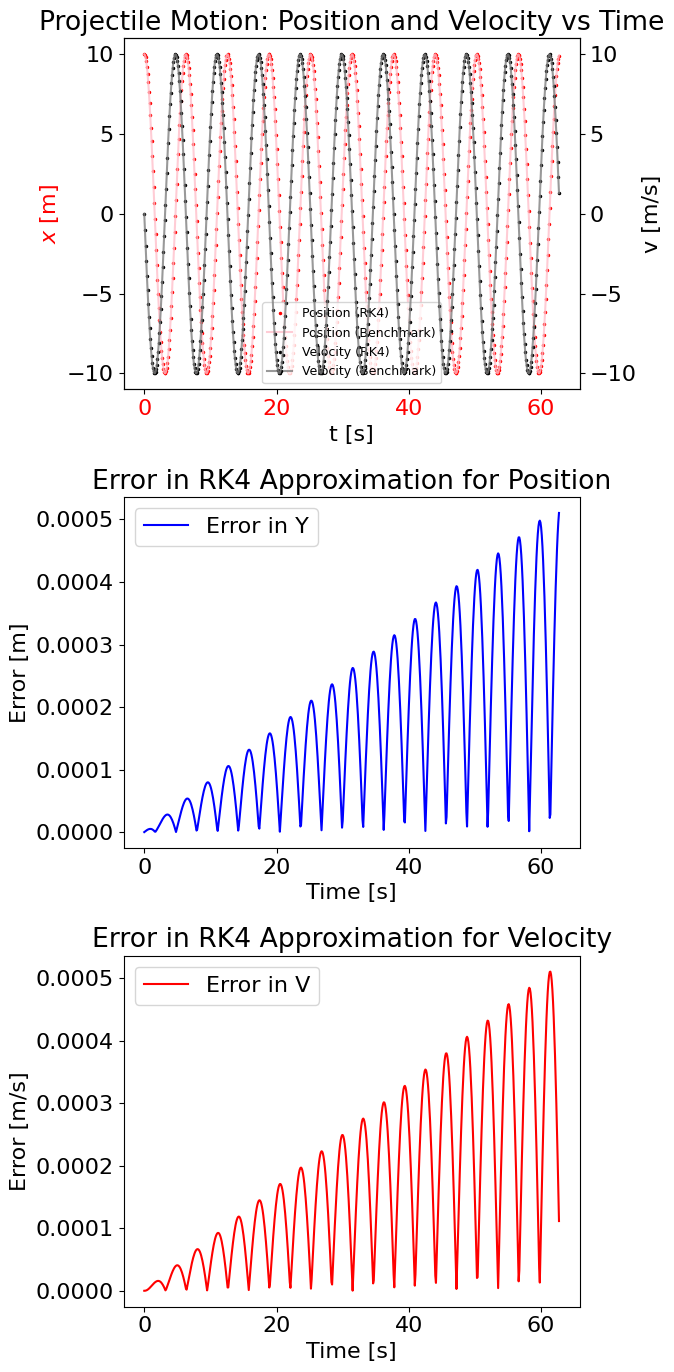

In [ ]:
x0 = 10 #Set initial values
v0 = 0
t0 = 0

tend = np.abs(2*10*(np.pi)) #Set end value

h = 0.1 #Set step (reduced from 0.1 to 0.01 to decrease error)

n = int((tend - t0) /h)

t = np.zeros(n) #Number of entries
x = np.zeros(n)
v = np.zeros(n)

t_bench = np.arange(0,(np.abs(2*10*(np.pi)))-0.1,h)
x_bench = x0*np.cos(t_bench) #Benchmark x

t_bench = np.arange(0,(np.abs(2*10*(np.pi)))-0.1,h)
v_bench = (-x0)*np.sin(t_bench) #Benchmark v

t[0] = t0
x[0] = x0
v[0] = v0

for i in range(n-1): #Perform RK4 on Mass_on_spring
    x_v_current = np.array([x[i], v[i]])
    x_v_next = RK4(t[i], x_v_current, Mass_on_spring, h)
    x[i+1] = x_v_next[0]
    v[i+1] = x_v_next[1]
    t[i+1] = t[i] + h

errorv = np.abs(x_bench - x) #Calculate error
errory = np.abs(v_bench - v)

plt.rcParams['font.size'] = 16
fig, axes = plt.subplots(3, 1, figsize=(7, 14))

ax1 = axes[0] #Create plots and twin axis
ax1.plot(t, x, color = 'red', marker = '.', markersize = 3, linestyle = '', label='Position (RK4)')
ax1.plot(t_bench, x_bench, color = 'pink',linestyle = '-', linewidth = 1.5, alpha = 0.8, label = 'Position (Benchmark)')
ax1.set_xlabel('t [s]')
ax1.set_ylabel('$x$ [m]', color='r')
ax1.tick_params(axis='x', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(t, (v) ,'k', marker = '.', markersize = 3, linestyle = '', label='Velocity (RK4)')
ax2.plot(t_bench, (v_bench), color = 'gray',linestyle = '-', linewidth = 1.5, alpha = 0.8, label = 'Velocity (Benchmark)')
ax2.set_ylabel('v [m/s]', color='k')
ax2.tick_params(axis='y', labelcolor='k')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, fontsize = 9, loc = 'lower center')
ax1.set_title('Projectile Motion: Position and Velocity vs Time')

ax_err_y = axes[1]
ax_err_y.plot(t, errory, 'b', label="Error in Y")
ax_err_y.set_ylabel('Error [m]')
ax_err_y.set_xlabel('Time [s]')
ax_err_y.legend()
ax_err_y.set_title('Error in RK4 Approximation for Position')

ax_err_v = axes[2]
ax_err_v.plot(t, errorv, 'r', label="Error in V")
ax_err_v.set_ylabel('Error [m/s]')
ax_err_v.set_xlabel('Time [s]')
ax_err_v.legend()
ax_err_v.set_title('Error in RK4 Approximation for Velocity')

plt.tight_layout()
plt.show()

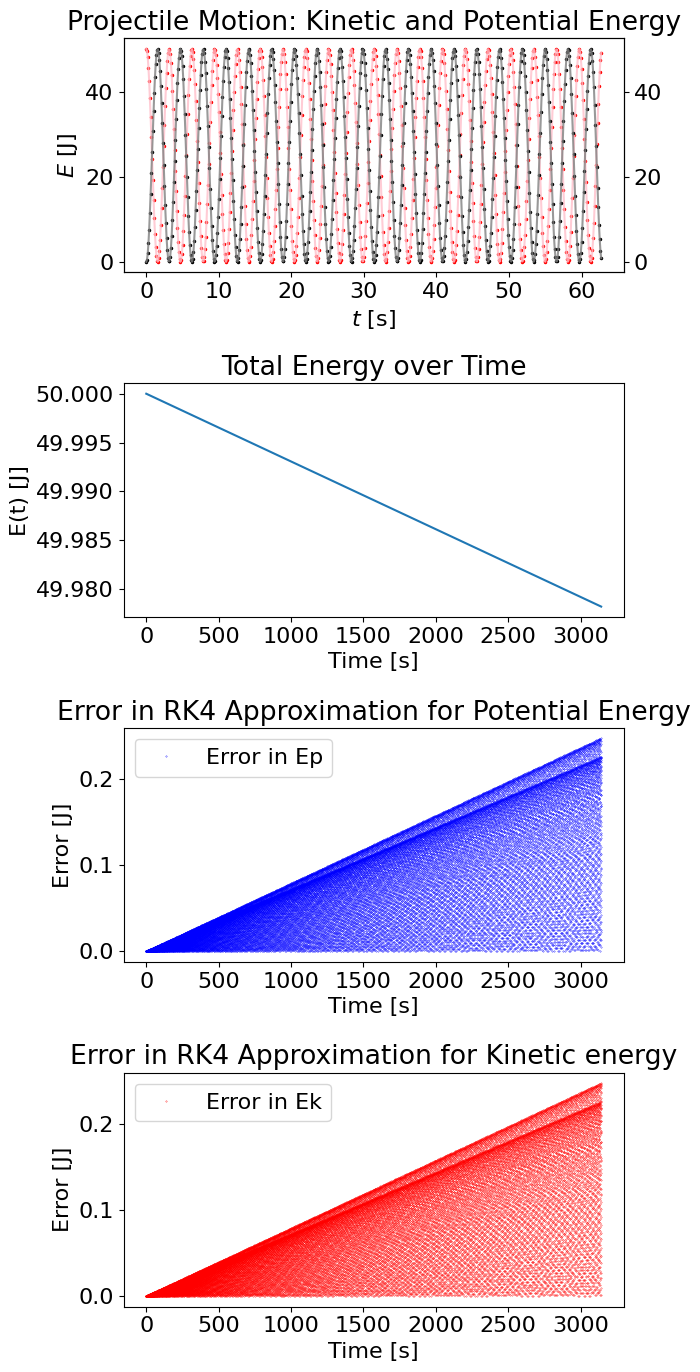

Conservaton of energy by E(t)/E(0) =  [1.         0.99999999 0.99999997 ... 0.99956433 0.99956432 0.99956431]


In [ ]:
t_end_new = np.abs(1000*(np.pi))
h = 0.1

num_points = int(round(t_end_new / h)) + 1

t_new = np.zeros(num_points) # Number of entries
x_new = np.zeros(num_points)
v_new = np.zeros(num_points)

# Create benchmark time array using linspace to ensure correct number of points and exact end_time
t_bench_new = np.linspace(t0, t_end_new, num_points)
x_bench_new = x0*np.cos(t_bench_new) #Benchmark x
v_bench_new = (-x0)*np.sin(t_bench_new) #Benchmark v

t_new[0] = t0
x_new[0] = x0
v_new[0] = v0

# The loop should iterate num_points - 1 times (for num_points data points)
for i in range(num_points - 1): # Perform RK4 on ODE
    x_v_current = np.array([x_new[i], v_new[i]])
    x_v_next = RK4(t_new[i], x_v_current, Mass_on_spring, h)
    x_new[i+1] = x_v_next[0]
    v_new[i+1] = x_v_next[1]
    t_new[i+1] = t_new[i] + h

Ep = 0.5 * (x**2)
Ek = 0.5 * (v**2)

# Now, after the loop, calculate the energies for the 1000 oscillations
Ep_new = 0.5 * (x_new**2)
Ek_new = 0.5 * (v_new**2)

Ep_bench = 0.5 * (x_bench**2)
Ek_bench = 0.5 * (v_bench**2)
# Calculate benchmark energies for 1000 oscillations
Ep_bench_new = 0.5 * (x_bench_new**2)
Ek_bench_new = 0.5 * (v_bench_new**2)

# Calculate errors using the appropriate benchmark and new arrays
errorEp = np.abs(Ep_bench_new - Ep_new)
errorEk = np.abs(Ek_bench_new - Ek_new)

plt.rcParams['font.size'] = 16
fig, axes = plt.subplots(4, 1, figsize=(7, 14))

ax1 = axes[0] #Create plots and twin axis
ax1.plot(t, Ep, color = 'red', marker = '.', markersize = 3, linestyle = '', label='Potential Energy (RK4)')
ax1.plot(t_bench, Ep_bench, color = 'pink',linestyle = '-', linewidth = 1.5, alpha = 0.8, label = 'Potential Energy (Benchmark)')
ax1.set_xlabel('$t$ [s]')
ax1.set_ylabel('$E$ [J]')

ax2 = ax1.twinx()
ax2.plot(t, Ek ,'k', marker = '.', markersize = 3, linestyle = '', label='Kinetic Energy (RK4)')
ax2.plot(t_bench, Ek_bench, color = 'gray',linestyle = '-', linewidth = 1.5, alpha = 0.8, label = 'Kinetic Energy (Benchmark)')
ax2.set_xlabel('$t$ [s]', color='k')
ax2.tick_params(axis='y', labelcolor='k')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.set_title('Projectile Motion: Kinetic and Potential Energy')

plt.tight_layout()

ax_total_energy = axes[1]
ax_total_energy.plot(t_new, Ep_new + Ek_new, '-', label='Total Energy (RK4)')
ax_total_energy.set_ylabel('E(t) [J]')
ax_total_energy.set_xlabel('Time [s]')
ax_total_energy.ticklabel_format(useOffset=False, style='plain')
ax_total_energy.set_title('Total Energy over Time')

ax_err_y = axes[2]
ax_err_y.plot(t_new, errorEp, 'b', marker = '.', linestyle = '', markersize = '0.5', label="Error in Ep")
ax_err_y.set_ylabel('Error [J]')
ax_err_y.set_xlabel('Time [s]')
ax_err_y.legend()
ax_err_y.set_title('Error in RK4 Approximation for Potential Energy')

ax_err_v = axes[3]
ax_err_v.plot(t_new, errorEk, 'r', marker = '.', linestyle = '', markersize = '0.5', label="Error in Ek")
ax_err_v.set_ylabel('Error [J]')
ax_err_v.set_xlabel('Time [s]')
ax_err_v.legend()
ax_err_v.set_title('Error in RK4 Approximation for Kinetic energy')

plt.tight_layout()
plt.show()

print('Conservaton of energy by E(t)/E(0) = ', (Ep_new + Ek_new)/(Ep_new[0] + Ek_new[0]));

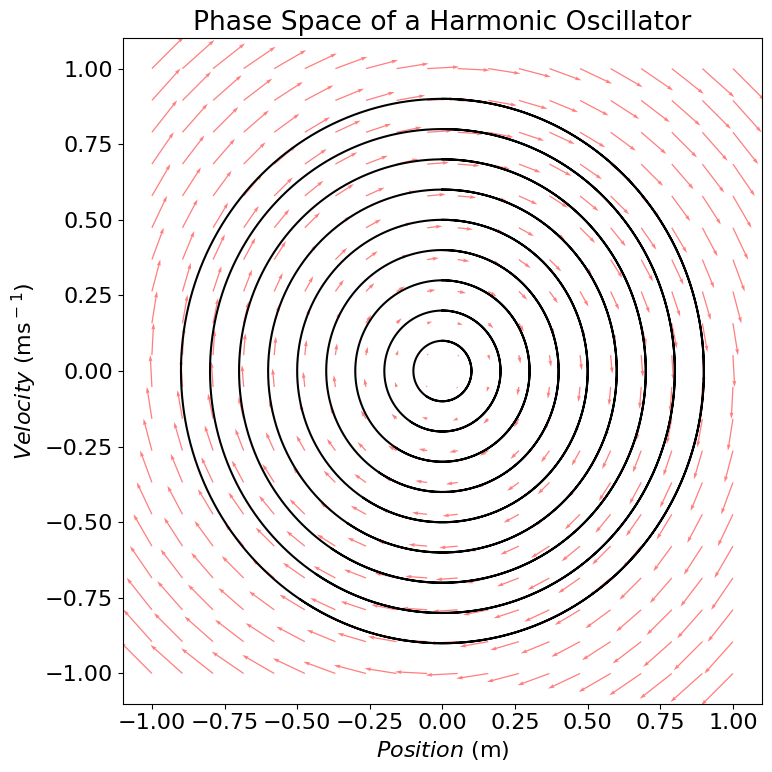

In [ ]:
N = np.arange(0,10,1)

x0_new = 0
v0_list = N*0.1

tend = np.abs(10) #Set end value

h_new = 0.01 #Set step

n = int((tend - t0) /h_new) + 1

plt.figure(figsize=(8, 8))

x_min, x_max = -1, 1
v_min, v_max = -1, 1
x_grid = np.linspace(x_min, x_max, 20)
v_grid = np.linspace(v_min, v_max, 20)
X_grid, V_grid = np.meshgrid(x_grid, v_grid)

U_grid, W_grid = Mass_on_spring_vector_field(X_grid, V_grid)

plt.quiver(X_grid, V_grid, U_grid, W_grid, color='r', alpha=0.5, scale=20, width=0.002)

for v0 in v0_list:
    x = np.zeros(n)
    v = np.zeros(n)
    t = np.zeros(n)

    x[0] = x0_new
    v[0] = v0
    t[0] = t0

    for i in range(n-1):
        x_v_current = np.array([x[i], v[i]])
        x_v_next = RK4(t[i], x_v_current, Mass_on_spring, h_new)
        x[i+1] = x_v_next[0]
        v[i+1] = x_v_next[1]
        t[i+1] = t[i] + h_new

    plt.plot(x, v, 'k')


plt.title('Phase Space of a Harmonic Oscillator')
plt.xlabel('$Position$ (m)')
plt.ylabel('$Velocity$ (ms$^-$$^1$)')

plt.tight_layout()
plt.show()

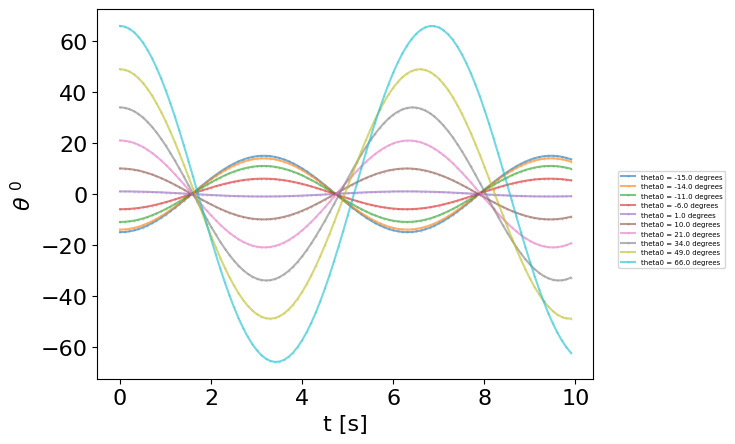

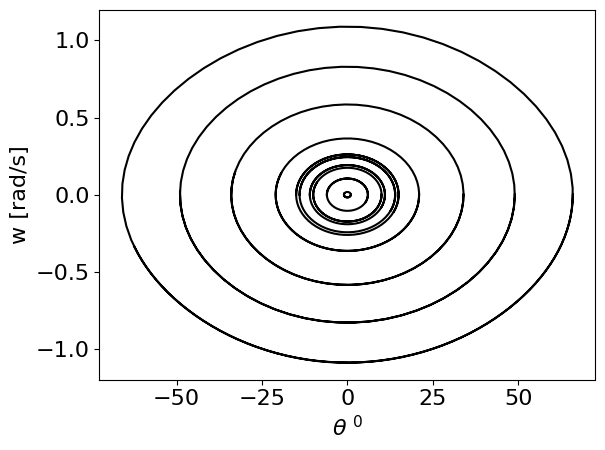

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


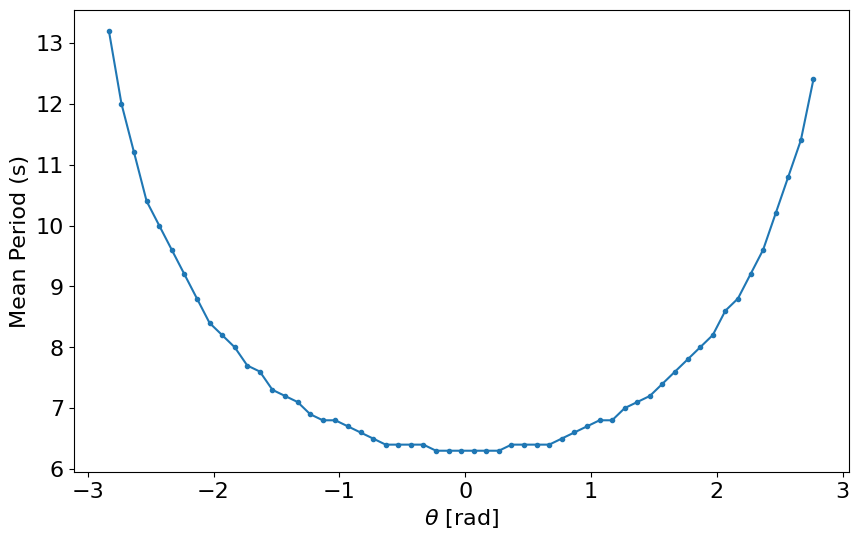

In [ ]:
t_out, thetas_out, theta0_out, w_out = theta(10,-15)

for i in range(len(thetas_out)):
    plt.plot(t_out, np.rad2deg(thetas_out[i]), marker='.', markersize=0.5, linestyle='-', alpha = 0.6, label='theta0 = %.1f degrees' % np.rad2deg(theta0_out[i]))

plt.xlabel('t [s]')
plt.ylabel('$\\theta$ $^0$')
plt.legend(fontsize=5, loc = (1.05,0.3))
plt.show()

for j in range(len(w_out)):
  plt.plot(np.rad2deg(thetas_out[j]), w_out[j], color = 'k')
plt.xlabel('$\\theta$ $^0$')
plt.ylabel('w [rad/s]')
plt.show()

periods = []
theta_list = []

for i in np.arange(-(np.pi) + 0.01, np.pi - 0.01, 0.1):
    theta_list.append(i)
    periods.append(Zero_cross_alg(1, i))

plt.figure(figsize=(10,6))
plt.plot(theta_list, periods, '.-')
plt.xlabel('$\\theta$ [rad]')
plt.ylabel('Mean Period (s)')
plt.show()

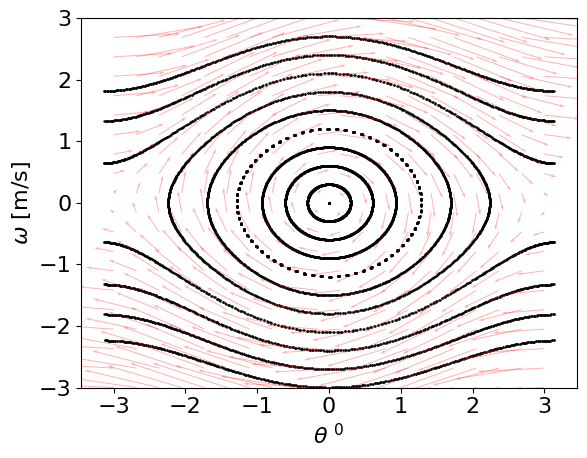

In [ ]:
t_vals, omega_vals, theta_vals, omega0 = omega(20, -10)

for i in range(len(omega_vals)):
    plt.scatter(theta_vals[i], omega_vals[i], s = 0.5, color = 'k', )

plt.xlabel('$\\theta$ $^0$')
plt.ylabel('$\\omega$ [m/s]')
plt.ylim(-3,3)

x_min, x_max = -3, 3
y_min, y_max = -3, 3
x_grid = np.linspace(x_min, x_max, 20)
v_grid = np.linspace(y_min, y_max, 20)
X_grid, V_grid = np.meshgrid(x_grid, v_grid)

U_grid, W_grid = Pendulum_vector_field(X_grid, V_grid)

plt.quiver(X_grid, V_grid, U_grid, W_grid, color='r', alpha=0.3, scale=20, width=0.002)

plt.savefig('Phaseplot.pdf', dpi = 700)

plt.show()

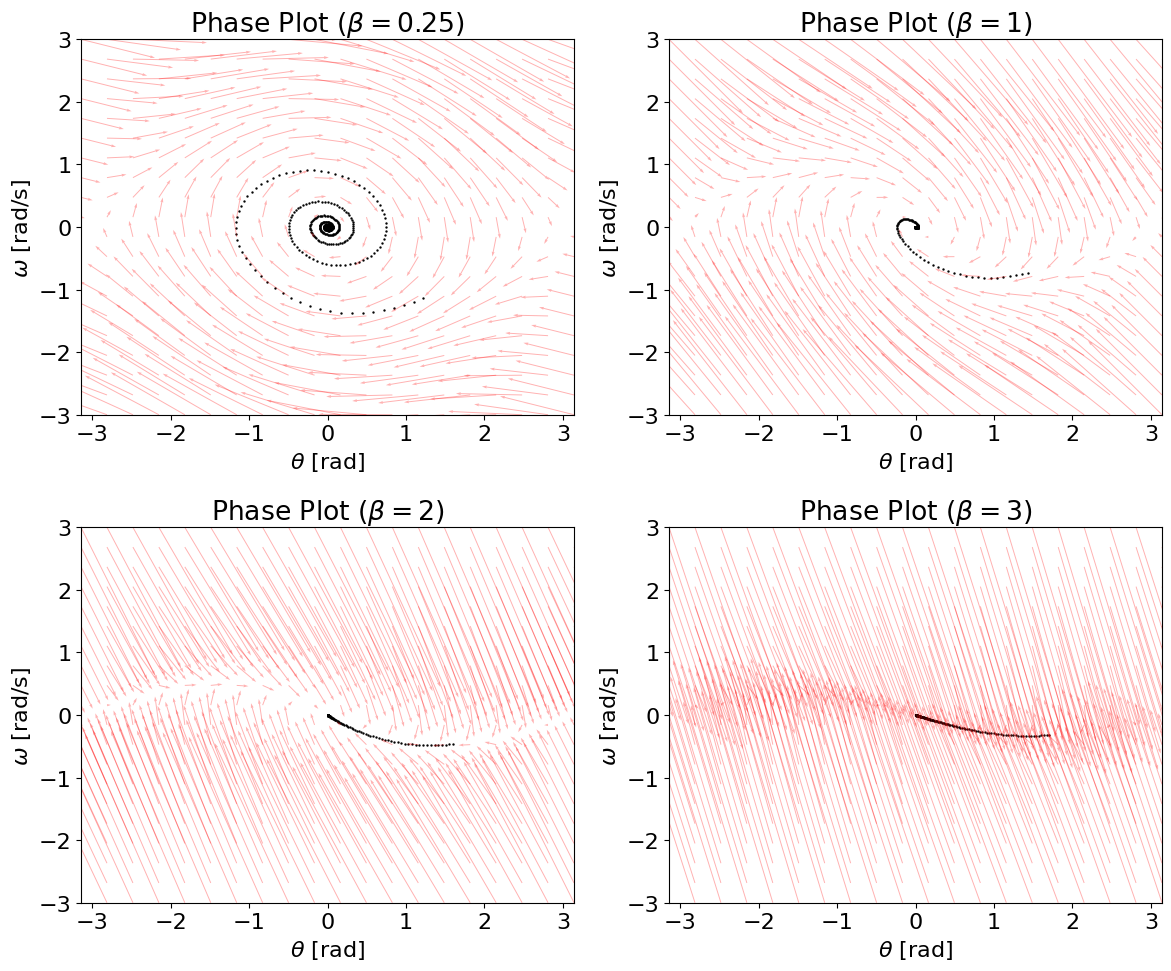

In [ ]:
betas = [0.25, 1, 2, 3]
theta_start = 90

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, beta in enumerate(betas):
    t_vals, omega_vals, theta_vals = damped_pendulum(theta_start, beta)

    axs[idx].scatter(theta_vals, omega_vals, s=0.5, color='k')

    x_min, x_max = -np.pi, np.pi
    y_min, y_max = -3, 3
    x_grid = np.linspace(x_min, x_max, 20)
    v_grid = np.linspace(y_min, y_max, 20)
    X_grid, V_grid = np.meshgrid(x_grid, v_grid)

    U_grid, W_grid = DampedODE_vector_field(X_grid, V_grid, beta)

    axs[idx].quiver(X_grid, V_grid, U_grid, W_grid, color='r', alpha=0.3, scale=20, width=0.002)

    axs[idx].set_title(f'Phase Plot ($\\beta = {beta}$)')
    axs[idx].set_xlabel('$\\theta$ [rad]')
    axs[idx].set_ylabel('$\\omega$ [rad/s]')
    axs[idx].set_xlim(x_min, x_max)
    axs[idx].set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('Phaseplot.pdf', dpi=700)
plt.show()

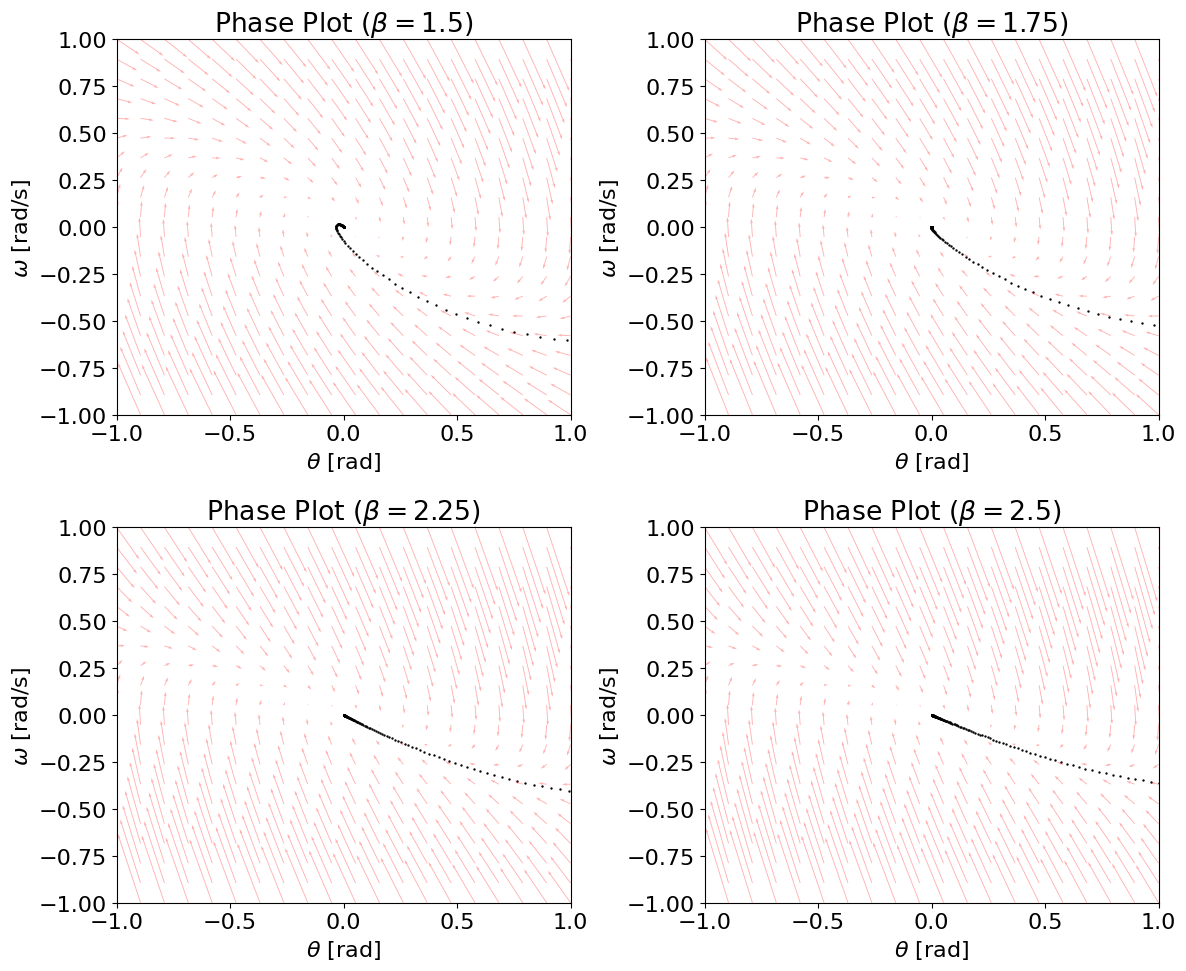

In [ ]:
betas = [1.5, 1.75, 2.25, 2.5]
theta_start = 90

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, beta in enumerate(betas):
    t_vals, omega_vals, theta_vals = damped_pendulum(theta_start, beta)

    axs[idx].scatter(theta_vals, omega_vals, s=0.5, color='k')

    x_min, x_max = -1, 1
    y_min, y_max = -1, 1
    x_grid = np.linspace(x_min, x_max, 20)
    v_grid = np.linspace(y_min, y_max, 20)
    X_grid, V_grid = np.meshgrid(x_grid, v_grid)

    U_grid, W_grid = DampedODE_vector_field(X_grid, V_grid, beta)

    axs[idx].quiver(X_grid, V_grid, U_grid, W_grid, color='r', alpha=0.3, scale=20, width=0.002)

    axs[idx].set_title(f'Phase Plot ($\\beta = {beta}$)')
    axs[idx].set_xlabel('$\\theta$ [rad]')
    axs[idx].set_ylabel('$\\omega$ [rad/s]')
    axs[idx].set_xlim(x_min, x_max)
    axs[idx].set_ylim(y_min, y_max)

plt.tight_layout()
plt.savefig('Phaseplot.pdf', dpi=700)
plt.show()

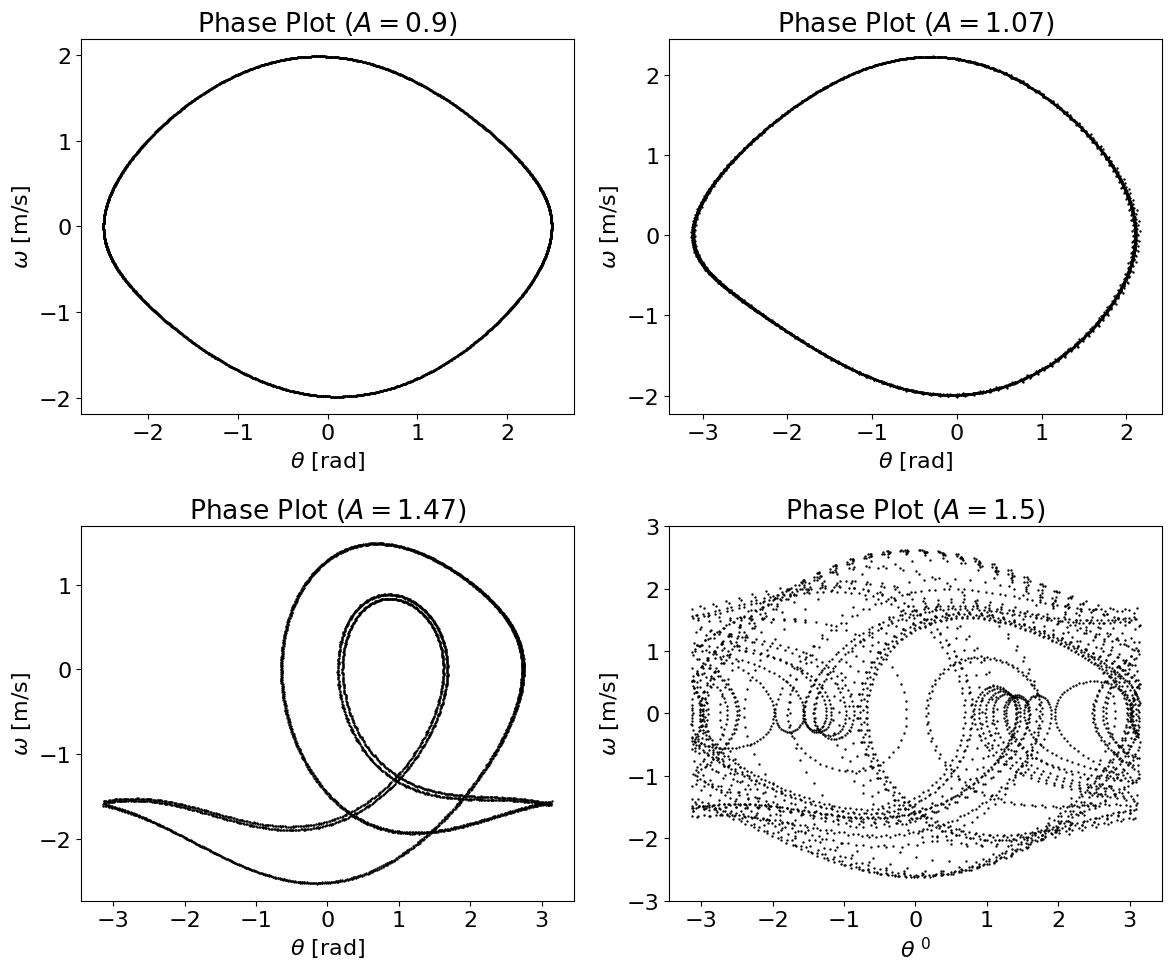

In [ ]:
As = [0.9, 1.07, 1.47, 1.5]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for idx, A in enumerate(As):
    t_vals, omega_vals, theta_vals, omega0 = driven_damped_pendulum(1, 0, A)
    t_vals = np.array(t_vals).flatten()
    omega_vals = np.array(omega_vals).flatten()
    theta_vals = np.array(theta_vals).flatten()
    mask = t_vals > 100
    if np.any(mask):
        axs[idx].scatter(theta_vals[mask], omega_vals[mask], s=0.5, color='k')

    axs[idx].set_title(f'Phase Plot ($A = {A}$)')
    axs[idx].set_xlabel('$\\theta$ [rad]')
    axs[idx].set_ylabel('$\\omega$ [m/s]')

plt.xlabel('$\\theta$ $^0$')
plt.ylabel('$\\omega$ [m/s]')
plt.ylim(-3,3)

plt.tight_layout()

plt.show()

x_min, x_max = -3, 3
y_min, y_max = -3, 3
x_grid = np.linspace(x_min, x_max, 20)
v_grid = np.linspace(y_min, y_max, 20)
X_grid, V_grid = np.meshgrid(x_grid, v_grid)

parameters = [(0.25, 0.9), (0.25, 1.5), (1.0, 0.9), (1.0, 1.5)]

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

quivers = []

for idx, (beta, A) in enumerate(parameters):
    ax = axs[idx]

    U, W = DrivenDampedODE_vector_field(X_grid, V_grid, beta, A, 0)

    Q = ax.quiver(X_grid, V_grid, U, W, color='r', alpha=0.3, scale=20, width=0.002)
    quivers.append(Q)

    ax.set_title(f"$\\beta={beta}$, $A={A}$ | Time: 0.00 s")
    ax.set_xlabel('$\\theta$ [rad]')
    ax.set_ylabel('$\\omega$ [m/s]')
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

plt.tight_layout()

def update_quiver(t):
    for idx, (beta, A) in enumerate(parameters):
        ax = axs[idx]
        Q = quivers[idx]

        U_new, W_new = DrivenDampedODE_vector_field(X_grid, V_grid, beta, A, t)

        Q.set_UVC(U_new, W_new)

        ax.set_title(f"$\\beta={beta}$, $A={A}$ | Time: {t:.2f} s")

    return quivers

t_frames = np.linspace(0, 20, 50)
anim = animation.FuncAnimation(fig, update_quiver, frames=t_frames, interval=100, blit=False)

plt.rcParams['animation.embed_limit'] = 500.0

plt.close(fig)
anim.save('phase_portraits.gif', writer='pillow', fps=10)

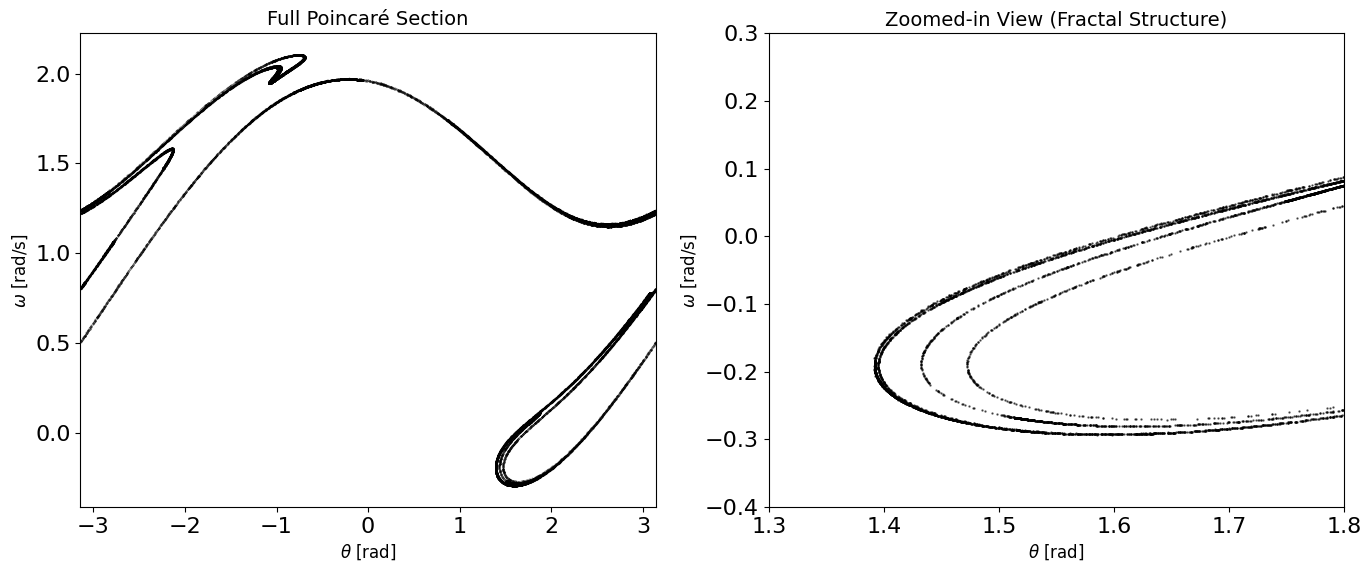

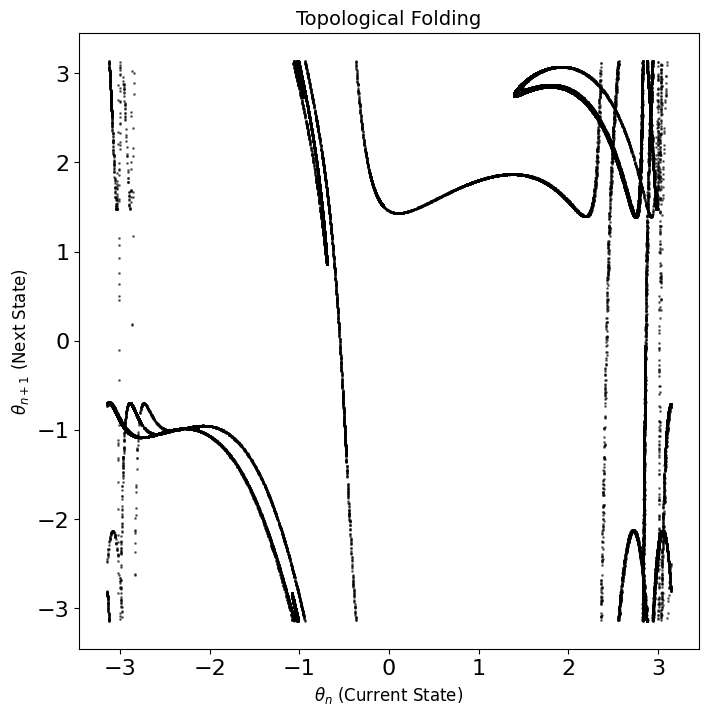

In [ ]:
theta0 = 0
omega0 = 0.0
t0 = 0.0

A_val = 1.5
omega_d = 0.67
beta_val = 0.5

N = 50000
steps = 100
skip = 100

dt = 2 * np.pi/(omega_d*steps)

time = np.arange(t0,N*2*np.pi / omega_d,dt)
nsteps = len(time)

omega = np.zeros(nsteps)
theta = np.zeros(nsteps)
omega[0] = omega0

theta[0] = theta0
omega_p = []
theta_p = []

for j in range(nsteps-1):
  x_v_current = np.array([theta[j], omega[j]])
  x_v_next = RK4(time[j], x_v_current, lambda current_t, current_theta_w: DrivenDampedPendulum(current_t, current_theta_w, beta_val, A_val), dt)
  theta[j+1] = x_v_next[0]
  omega[j+1] = x_v_next[1]

offset = steps//4
start_idx = skip * steps + offset

theta_p = theta[start_idx :: steps]
omega_p = omega[start_idx :: steps]

theta_p_wrapped = (theta_p + np.pi) % (2 * np.pi) - np.pi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(theta_p_wrapped, omega_p, s=0.1, color='black', alpha=0.5)
ax1.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax1.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax1.set_title('Full Poincaré Section', fontsize=14)
ax1.set_xlim(-np.pi, np.pi)

ax2.scatter(theta_p_wrapped, omega_p, s=0.5, color='k', alpha=0.6)
ax2.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax2.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax2.set_title('Zoomed-in View (Fractal Structure)', fontsize=14)

ax2.set_xlim(1.3, 1.8)
ax2.set_ylim(-0.4, 0.3)

plt.tight_layout()
plt.savefig('poincare_plot.pdf', dpi=700)

# We take all Poincaré points except the last one for the X-axis
theta_n = theta_p_wrapped[:-1]

# We take all Poincaré points except the first one for the Y-axis
theta_n_plus_1 = theta_p_wrapped[1:]

plt.figure(figsize=(8, 8))
plt.scatter(theta_n, theta_n_plus_1, s=1.0, color='k', alpha=0.5)
plt.xlabel('$\\theta_n$ (Current State)', fontsize=12)
plt.ylabel('$\\theta_{n+1}$ (Next State)', fontsize=12)
plt.title('Topological Folding', fontsize=14)
plt.savefig('Topological_folding.pdf', dpi=700)
plt.show()

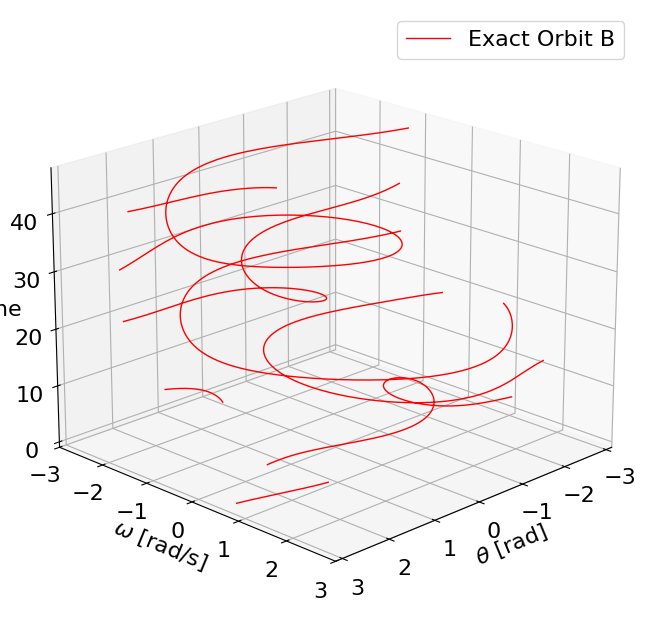

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- System Parameters ---
A_val = 1.5
omega_d = 0.67
beta_val = 0.5
T = 2 * np.pi / omega_d

# --- Exact Coordinates Found via Root-Finding ---
# These are the precise starting points for two different unstable periodic orbits
# Orbit A: A Period-1 orbit (repeats every 1 cycle)
p1_th_exact = -1.2291
p1_om_exact = -1.0664

# Orbit B: A different Period-1 orbit (we will use this to show the braiding)
p2_th_exact = 1.2587
p2_om_exact = 1.0452

# --- Improved Continuous Integration Function ---
def integrate_exact_path(th0, om0, num_periods, steps_per_period=200):
    dt = T / steps_per_period
    n_steps = num_periods * steps_per_period

    th_path = np.zeros(n_steps)
    om_path = np.zeros(n_steps)
    t_path = np.zeros(n_steps)

    th, om = th0, om0

    for i in range(n_steps):
        t = i * dt

        # We must wrap theta to [-pi, pi] to keep it on the cylinder!
        # This prevents the x-axis from wandering off to 10.0
        th_wrapped = (th + np.pi) % (2 * np.pi) - np.pi

        th_path[i] = th_wrapped
        om_path[i] = om
        t_path[i] = t

        # RK4 Steps
        k1_th = om * dt
        k1_om = (-np.sin(th) - beta_val * om + A_val * np.cos(omega_d * t)) * dt

        th2 = th + 0.5 * k1_th
        om2 = om + 0.5 * k1_om
        k2_th = om2 * dt
        k2_om = (-np.sin(th2) - beta_val * om2 + A_val * np.cos(omega_d * (t + 0.5*dt))) * dt

        th3 = th + 0.5 * k2_th
        om3 = om + 0.5 * k2_om
        k3_th = om3 * dt
        k3_om = (-np.sin(th3) - beta_val * om3 + A_val * np.cos(omega_d * (t + 0.5*dt))) * dt

        th4 = th + k3_th
        om4 = om + k3_om
        k4_th = om4 * dt
        k4_om = (-np.sin(th4) - beta_val * om4 + A_val * np.cos(omega_d * (t + dt))) * dt

        th += (k1_th + 2*k2_th + 2*k3_th + k4_th) / 6.0
        om += (k1_om + 2*k2_om + 2*k3_om + k4_om) / 6.0

    return th_path, om_path, t_path

# --- Call integrate_exact_path to define th_a, om_a, t_a, etc. ---
num_periods_to_integrate = 5 # Example: Integrate for 100 periods
th_a, om_a, t_a = integrate_exact_path(p1_th_exact, p1_om_exact, num_periods_to_integrate)
th_b, om_b, t_b = integrate_exact_path(p2_th_exact, p2_om_exact, num_periods_to_integrate)

# --- Quick Fix: Break the wrapping lines ---
def hide_wrapping_lines(th, om, t):
    # Find indices where the jump is suspiciously large (greater than pi)
    jumps = np.where(np.abs(np.diff(th)) > np.pi)[0] + 1

    # Insert 'NaN' at those points to make Matplotlib lift its pen
    th_clean = np.insert(th, jumps, np.nan)
    om_clean = np.insert(om, jumps, np.nan)
    t_clean = np.insert(t, jumps, np.nan)

    return th_clean, om_clean, t_clean

# Clean the arrays before plotting
th_a_clean, om_a_clean, t_a_clean = hide_wrapping_lines(th_a, om_a, t_a)
th_b_clean, om_b_clean, t_b_clean = hide_wrapping_lines(th_b, om_b, t_b)

# --- Plot the Cleaned 3D Braid ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Use the cleaned arrays here!
#ax.plot(th_a_clean, om_a_clean, t_a_clean, color='k', linewidth=2, label='Exact Orbit A')
ax.plot(th_b_clean, om_b_clean, t_b_clean, color='red', linewidth=1, label='Exact Orbit B')

ax.set_xlabel('$\\theta$ [rad]')
ax.set_ylabel('$\\omega$ [rad/s]')
ax.set_zlabel('Time')

ax.set_xlim(-np.pi, np.pi)
ax.set_ylim(-3, 3)

ax.legend()
ax.view_init(elev=20, azim=45)
plt.savefig('Topological_skeleton.pdf', dpi=700)
plt.show()

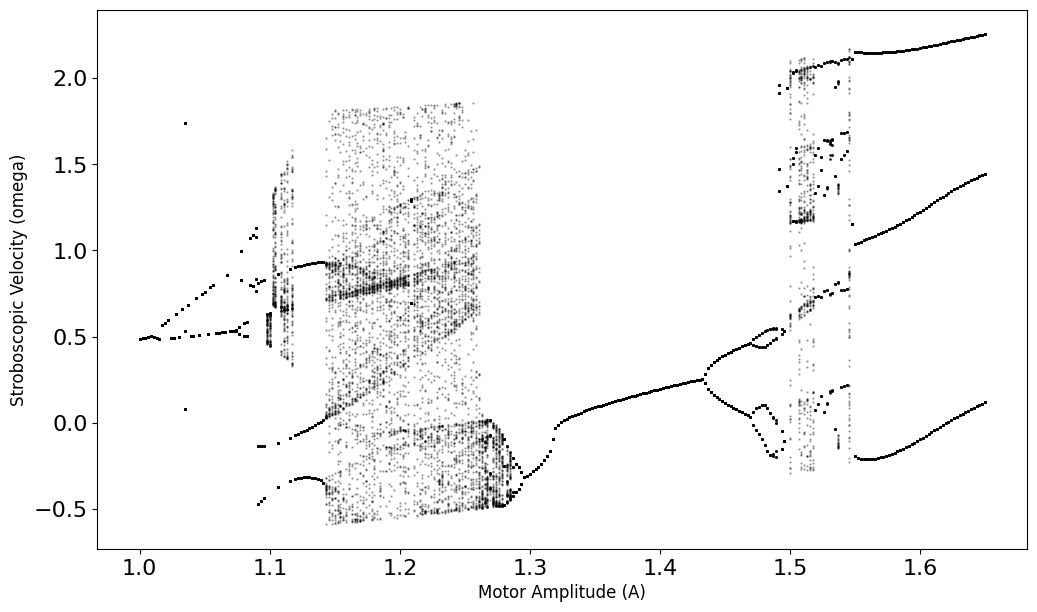

In [ ]:
# --- Base Parameters ---
omega_d = 0.67
beta_val = 0.5

# For a good bifurcation diagram, we need high resolution on the A values.
# Let's sweep A from 1.35 to 1.5 to watch it transition into chaos.
A_vals = np.linspace(1, 1.65, 300)

# We can use fewer cycles per A value to speed things up
steps = 100
skip = 400      # Throw away the first 60 cycles to let it settle
N_cycles = 500  # Total cycles per A value
dt = 2 * np.pi / (omega_d * steps)

nsteps = N_cycles * steps
time_arr = np.arange(0, nsteps * dt, dt)

# Arrays to hold our final plot data
A_plot = []
omega_plot = []

# --- The Outer Loop: Slowly cranking up the motor power ---
for A in A_vals:
    theta = np.zeros(nsteps)
    omega = np.zeros(nsteps)

    # We start from rest for every new A value
    theta[0] = 0.0
    omega[0] = 0.0

    # --- The Inner Loop: Simulating the pendulum ---
    for j in range(nsteps-1):
      x_v_current = np.array([theta[j], omega[j]])
      x_v_next = RK4(time_arr[j], x_v_current, lambda current_t, current_theta_w: DrivenDampedPendulum(current_t, current_theta_w, beta_val, A), dt)
      theta[j+1] = x_v_next[0]
      omega[j+1] = x_v_next[1]

    if theta[j+1] > np.pi:
        theta[j+1] -= 2*np.pi
    if theta[j+1] < -np.pi:
        theta[j+1] += 2*np.pi

    # --- Extract the Poincaré Section for this specific A ---
    offset = steps // 4
    omega_p = omega[skip * steps + offset :: steps]

    # Store the results. We duplicate the A value so it matches the number of dots.
    for om_p in omega_p:
        A_plot.append(A)
        omega_plot.append(om_p)

# --- Plotting the Bifurcation Diagram ---
plt.figure(figsize=(12, 7))

# We use tiny dots with low alpha so dense areas look darker
plt.scatter(A_plot, omega_plot, s=0.5, color='black', alpha=0.3)

plt.xlabel('Amplitude (A)', fontsize=12)
plt.ylabel('(omega)', fontsize=12)
plt.savefig('Bifurcation_diagram.pdf', dpi=700)
plt.show()


In [ ]:
theta0 = 0
omega0 = 0.0
t0 = 0.0

A_val = 1.5
omega_d = 0.67
beta_val = 0.5

N = 50000
steps = 1000
skip = 100

dt = 2 * np.pi/(omega_d*steps)

time = np.arange(t0,N*2*np.pi / omega_d,dt)
nsteps = len(time)

omega = np.zeros(nsteps)
theta = np.zeros(nsteps)
omega[0] = omega0

theta[0] = theta0
omega_p = []
theta_p = []

for j in range(nsteps-1):
  x_v_current = np.array([theta[j], omega[j]])
  x_v_next = RK4(time[j], x_v_current, lambda current_t, current_theta_w: DrivenDampedPendulum(current_t, current_theta_w, beta_val, A_val), dt)
  theta[j+1] = x_v_next[0]
  omega[j+1] = x_v_next[1]

theta = theta[skip*steps:]
omega = omega[skip*steps:]
time = time[skip*steps:]
offset = steps//4
maxindex = int(( N-skip )*steps-offset)

theta_poincare = theta[skip * steps + offset :: steps]
omega_poincare = omega[skip * steps + offset :: steps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(theta_poincare, omega_poincare, s=0.1, color='black', alpha=0.5)
ax1.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax1.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax1.set_title('Full Poincaré Section', fontsize=14)
ax1.set_xlim(-np.pi, np.pi)

ax2.scatter(theta_poincare, omega_poincare, s=0.5, color='k', alpha=0.6)
ax2.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax2.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax2.set_title('Zoomed-in View (Fractal Structure)', fontsize=14)

ax2.set_xlim(1.3, 1.8)
ax2.set_ylim(-0.4, 0.3)

plt.tight_layout()
plt.savefig('poincare_plot_ultra.pdf', dpi=700)



KeyboardInterrupt: 

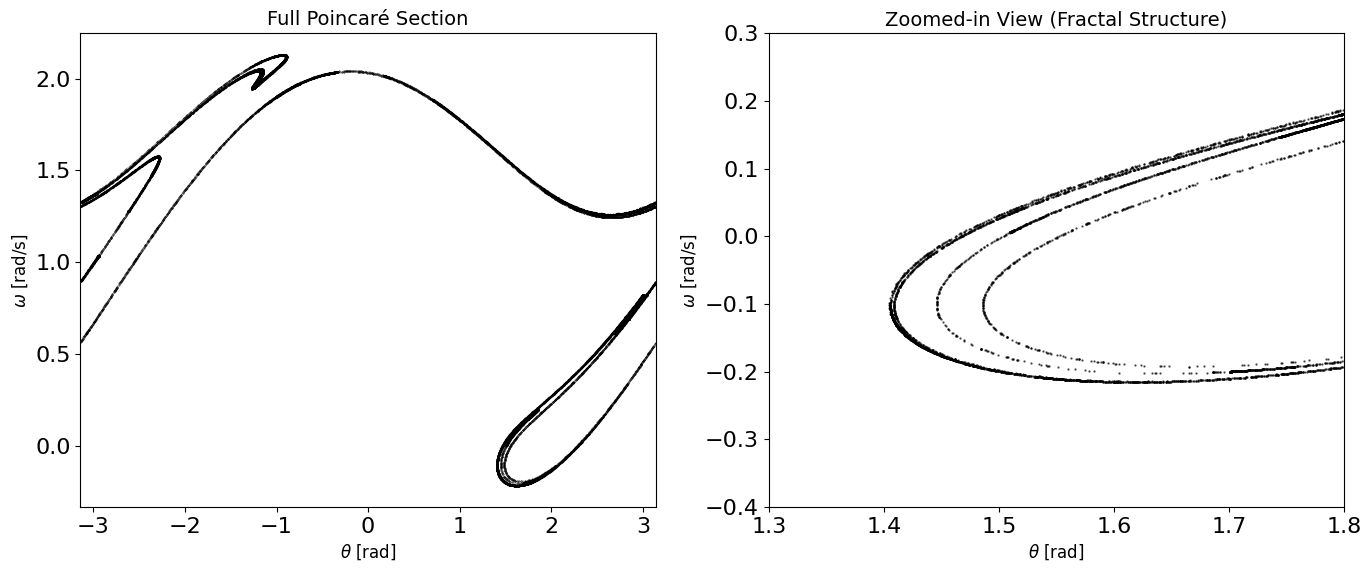

In [ ]:
theta0 = 0
omega0 = 0.0
t0 = 0.0

A_val = 1.5
omega_d = 0.67
beta_val = 0.5

N = 50000
steps = 25
skip = 100

dt = 2 * np.pi/(omega_d*steps)

time = np.arange(t0,N*2*np.pi / omega_d,dt)
nsteps = len(time)

omega = np.zeros(nsteps)
theta = np.zeros(nsteps)
omega[0] = omega0

theta[0] = theta0
omega_p = []
theta_p = []

for j in range(nsteps-1):
  x_v_current = np.array([theta[j], omega[j]])
  x_v_next = RK4(time[j], x_v_current, lambda current_t, current_theta_w: DrivenDampedPendulum(current_t, current_theta_w, beta_val, A_val), dt)
  theta[j+1] = x_v_next[0]
  omega[j+1] = x_v_next[1]

offset = steps//4
start_idx = skip * steps + offset

theta_p = theta[start_idx :: steps]
omega_p = omega[start_idx :: steps]

theta_p_wrapped = (theta_p + np.pi) % (2 * np.pi) - np.pi

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(theta_p_wrapped, omega_p, s=0.1, color='black', alpha=0.5)
ax1.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax1.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax1.set_title('Full Poincaré Section', fontsize=14)
ax1.set_xlim(-np.pi, np.pi)

ax2.scatter(theta_p_wrapped, omega_p, s=0.5, color='k', alpha=0.6)
ax2.set_xlabel('$\\theta$ [rad]', fontsize=12)
ax2.set_ylabel('$\\omega$ [rad/s]', fontsize=12)
ax2.set_title('Zoomed-in View (Fractal Structure)', fontsize=14)

ax2.set_xlim(1.3, 1.8)
ax2.set_ylim(-0.4, 0.3)

plt.tight_layout()
plt.savefig('poincare_plot_low_def.pdf', dpi=700)